In [0]:
#  1. LOAD PACKAGES AND SIMULATE DATA 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

def generate_professional_banking_data(n_users=20000):
    np.random.seed(42)
    
    # Base demographic and financial data
    data = pd.DataFrame({
        'user_id': range(1, n_users + 1),
        'group': np.random.choice(['control', 'treatment'], size=n_users),
        'age': np.random.randint(18, 80, n_users),
        'credit_score': np.random.normal(650, 100, n_users).clip(300, 850),
        'income': np.random.normal(55000, 20000, n_users).clip(15000, 200000),
        'device': np.random.choice(['Mobile', 'Desktop', 'Tablet'], size=n_users, p=[0.6, 0.3, 0.1]),
        'account_type': np.random.choice(['Savings', 'Checking', 'Premium'], size=n_users, p=[0.4, 0.5, 0.1]),
        'years_with_bank': np.random.randint(0, 15, n_users)
    })

    def calculate_conversion(row):
        # Start with a base probability
        prob = 0.05
        
        # Financial influence
        if row['income'] > 80000: prob += 0.02
        if row['account_type'] == 'Premium': prob += 0.03
        
        # THE TREATMENT EFFECT (The "Story")
        # We simulate that the treatment is a "Mobile-First" UI redesign
        if row['group'] == 'treatment':
            if row['device'] == 'Mobile':
                prob += 0.04  # Mobile users love it!
            elif row['device'] == 'Desktop':
                prob -= 0.02  # Desktop users find it confusing
            
            # Age interaction: Tech adoption gap
            if row['age'] > 60:
                prob -= 0.03
        
        # Add random noise
        prob += np.random.normal(0, 0.01)
        return np.random.binomial(1, max(0.001, min(prob, 0.99)))

    data['converted'] = data.apply(calculate_conversion, axis=1)
    return data

In [0]:
#  2. ANALYTICS ENGINE 
class ABTestEngine:
    def __init__(self, df):
        self.df = df
        self.ctrl = df[df['group'] == 'control']
        self.trt = df[df['group'] == 'treatment']

    def run_all_tests(self):
        # Frequentist
        z_stat, p_val = proportions_ztest([self.trt['converted'].sum(), self.ctrl['converted'].sum()], 
                                          [len(self.trt), len(self.ctrl)])
        
        # Bayesian
        a_c, b_c = 1 + self.ctrl['converted'].sum(), 1 + (len(self.ctrl) - self.ctrl['converted'].sum())
        a_t, b_t = 1 + self.trt['converted'].sum(), 1 + (len(self.trt) - self.trt['converted'].sum())
        samples_c = np.random.beta(a_c, b_c, 10000)
        samples_t = np.random.beta(a_t, b_t, 10000)
        
        return {
            "p_value": p_val,
            "prob_trt_wins": (samples_t > samples_c).mean(),
            "samples_c": samples_c,
            "samples_t": samples_t,
            "lift": (self.trt['converted'].mean() - self.ctrl['converted'].mean()) / self.ctrl['converted'].mean()
        }

    def get_segment_lift(self, column):
        report = self.df.groupby([column, 'group'], observed=True)['converted'].mean().unstack()
        report['Lift %'] = (report['treatment'] - report['control']) / report['control'] * 100
        return report

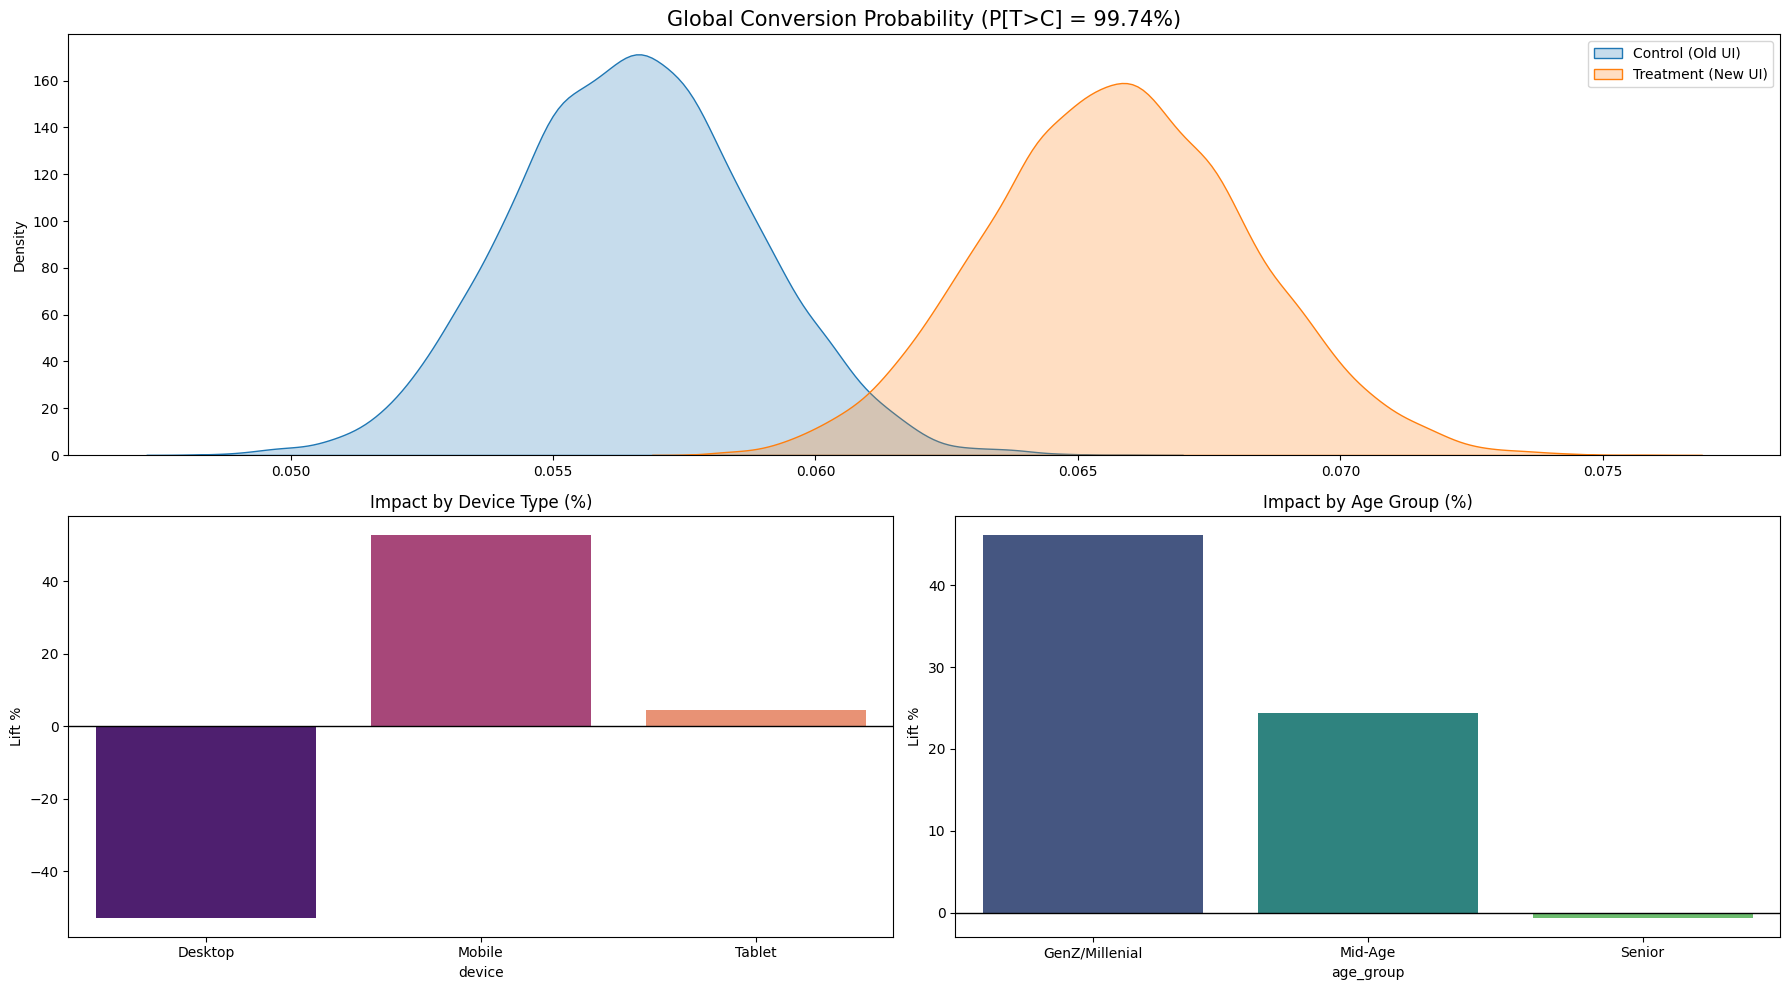

Overall Lift: 16.57%
Frequentist P-Value: 0.0058
--------------------------------------------------
SRM PASS: True (p=0.8574)
FREQUENTIST P-VALUE: 0.1356
BOOTSTRAP 95% CI: [-1.1739%, 0.1593%]
EXPECTED LIFT: -0.51%
--------------------------------------------------
SEGMENTATION INSIGHT:
age_seg
Young     19.873990
Mid      -17.796027
Senior   -33.193299
Name: Lift %, dtype: float64


In [0]:
##  3. EXECUTION AND VISUALIZATION 
df = generate_professional_banking_data()
engine = ABTestEngine(df)
results = engine.run_all_tests()

# Prepare Segment Data
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 80], labels=['GenZ/Millenial', 'Mid-Age', 'Senior'])
age_lift = engine.get_segment_lift('age_group')
device_lift = engine.get_segment_lift('device')

# Plotting
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2)

# 1. Overall Bayesian Distributions
ax1 = fig.add_subplot(gs[0, :])
sns.kdeplot(results['samples_c'], label='Control (Old UI)', fill=True, ax=ax1)
sns.kdeplot(results['samples_t'], label='Treatment (New UI)', fill=True, ax=ax1)
ax1.set_title(f"Global Conversion Probability (P[T>C] = {results['prob_trt_wins']:.2%})", fontsize=15)
ax1.legend()

# 2. Lift by Device
ax2 = fig.add_subplot(gs[1, 0])
sns.barplot(x=device_lift.index, y=device_lift['Lift %'], palette='magma', ax=ax2, hue=device_lift.index, legend=False)
ax2.axhline(0, color='black', lw=1)
ax2.set_title("Impact by Device Type (%)", fontsize=12)

# 3. Lift by Age
ax3 = fig.add_subplot(gs[1, 1])
sns.barplot(x=age_lift.index, y=age_lift['Lift %'], palette='viridis', ax=ax3, hue=age_lift.index, legend=False)
ax3.axhline(0, color='black', lw=1)
ax3.set_title("Impact by Age Group (%)", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Overall Lift: {results['lift']:.2%}")
print(f"Frequentist P-Value: {results['p_value']:.4f}")



In [0]:
#  4. EXECUTIVE SUMMARY 
print("-" * 50)
print(f"SRM PASS: {srm['is_valid']} (p={srm['p_value']:.4f})")
print(f"FREQUENTIST P-VALUE: {freq['p_value']:.4f}")
print(f"BOOTSTRAP 95% CI: [{boot['ci'][0]:.4%}, {boot['ci'][1]:.4%}]")
print(f"EXPECTED LIFT: {np.mean(boot['diffs']):.2%}")
print("-" * 50)
print("SEGMENTATION INSIGHT:")
print(seg_report['Lift %'])

--------------------------------------------------
SRM PASS: True (p=0.8574)
FREQUENTIST P-VALUE: 0.1356
BOOTSTRAP 95% CI: [-1.1739%, 0.1593%]
EXPECTED LIFT: -0.51%
--------------------------------------------------
SEGMENTATION INSIGHT:
age_seg
Young     19.873990
Mid      -17.796027
Senior   -33.193299
Name: Lift %, dtype: float64
